In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier


In [143]:
import pandas as pd

# Load Morocco dataset
morocco_df = pd.read_parquet("dataset/fire.parquet")

# Load Indian synthetic dataset
india_df = pd.read_csv("dataset/india_synthetic_wildfire_100k_balanced.csv")

print("Morocco shape:", morocco_df.shape)
print("India shape:", india_df.shape)

Morocco shape: (934586, 278)
India shape: (100000, 8)


In [145]:
print("Morocco columns:\n", morocco_df.columns)
print("\nIndia columns:\n", india_df.columns)

Morocco columns:
 Index(['acq_date', 'latitude', 'longitude', 'is_holiday', 'day_of_week',
       'day_of_year', 'is_weekend', 'NDVI', 'SoilMoisture', 'sea_distance',
       ...
       'wind_gust_quarterly_mean', 'dew_point_quarterly_mean',
       'average_temperature_yearly_mean', 'maximum_temperature_yearly_mean',
       'minimum_temperature_yearly_mean', 'precipitation_yearly_mean',
       'snow_depth_yearly_mean', 'wind_gust_yearly_mean',
       'dew_point_yearly_mean', 'is_fire'],
      dtype='object', length=278)

India columns:
 Index(['latitude', 'longitude', 'sea_distance', 'NDVI', 'SoilMoisture',
       'dew_point_weekly_mean', 'average_temperature_weekly_mean', 'is_fire'],
      dtype='object')


In [147]:
common_cols = list(set(morocco_df.columns).intersection(set(india_df.columns)))

morocco_df = morocco_df[common_cols]
india_df = india_df[common_cols]

In [149]:
combined_df = pd.concat([morocco_df, india_df], axis=0)
combined_df = combined_df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Combined shape:", combined_df.shape)

Combined shape: (1034586, 8)


In [151]:
X = combined_df.drop("is_fire", axis=1)
y = combined_df["is_fire"]

In [153]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [155]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train_scaled, y_train)


RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=300,
                       random_state=42)

In [157]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]


In [159]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.9161946591300112

Classification Report:

              precision    recall  f1-score   support

         0.0       0.93      0.90      0.91    129324
         1.0       0.90      0.94      0.92    129323

    accuracy                           0.92    258647
   macro avg       0.92      0.92      0.92    258647
weighted avg       0.92      0.92      0.92    258647



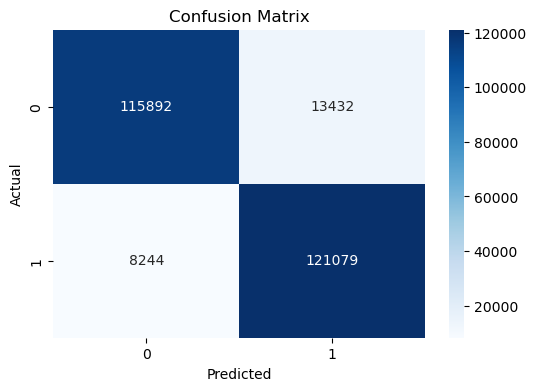

In [161]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


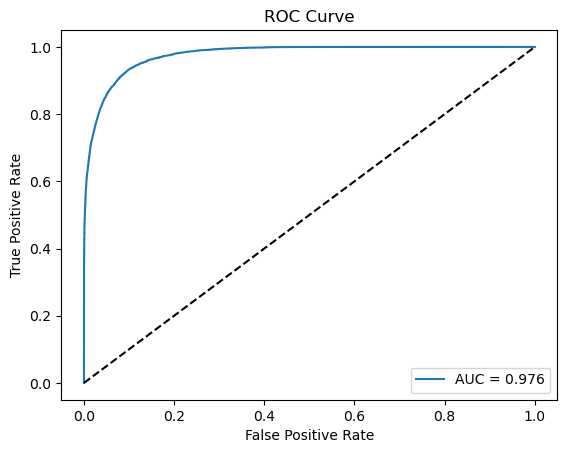

In [163]:
auc = roc_auc_score(y_test, y_prob)
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


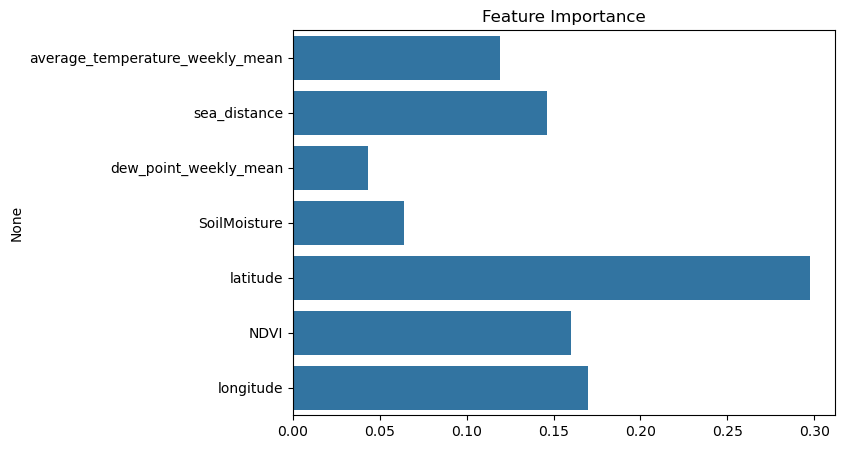

In [165]:
importances = model.feature_importances_
feat_names = X.columns

plt.figure(figsize=(7,5))
sns.barplot(x=importances, y=feat_names)
plt.title("Feature Importance")
plt.show()


In [175]:
def predict_fire(latitude, longitude, sea_distance, NDVI, SoilMoisture, 
                 dew_point_weekly_mean, average_temperature_weekly_mean):

    input_dict = {
        'latitude': latitude,
        'longitude': longitude,
        'sea_distance': sea_distance,
        'NDVI': NDVI,
        'SoilMoisture': SoilMoisture,
        'dew_point_weekly_mean': dew_point_weekly_mean,
        'average_temperature_weekly_mean': average_temperature_weekly_mean
    }

    # Create dataframe
    data = pd.DataFrame([input_dict])

    # 🔥 Reorder according to training order
    data = data[scaler.feature_names_in_]

    data_scaled = scaler.transform(data)

    prob = model.predict_proba(data_scaled)[0][1]
    confidence = max(prob, 1 - prob)

    return prob, confidence
# Example test
prob, confidence = predict_fire(
    latitude=30.3,
    longitude=78.0,
    sea_distance=300000,
    NDVI=1500,
    SoilMoisture=7,
    dew_point_weekly_mean=50,
    average_temperature_weekly_mean=98
)

print(prob, confidence)

0.5010332334963146 0.5010332334963146


In [177]:

joblib.dump(model, "models/fire.pkl")
joblib.dump(scaler, "models/fire_scaler.pkl")

print("Model & Scaler Saved Successfully!")

Model & Scaler Saved Successfully!


In [117]:
# HEATMAP OF FEATURE CORRELATIONS
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
corr = df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap of Features", fontsize=14)
plt.show()


KeyboardInterrupt: 

<Figure size 1000x600 with 0 Axes>

In [33]:
# --- Testing Multiple Algorithms: Imports ---

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [35]:
# --- Logistic Regression ---

log_reg = LogisticRegression(max_iter=2000)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

print("🔹 Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))


🔹 Logistic Regression Results
Accuracy: 0.9884169884169884

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.99       130
           1       0.98      0.99      0.99       129

    accuracy                           0.99       259
   macro avg       0.99      0.99      0.99       259
weighted avg       0.99      0.99      0.99       259

Confusion Matrix:
 [[128   2]
 [  1 128]]


In [37]:
# --- Decision Tree Classifier ---

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("🔹 Decision Tree Results")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))


🔹 Decision Tree Results
Accuracy: 0.9845559845559846

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.98       130
           1       0.98      0.99      0.98       129

    accuracy                           0.98       259
   macro avg       0.98      0.98      0.98       259
weighted avg       0.98      0.98      0.98       259

Confusion Matrix:
 [[127   3]
 [  1 128]]


In [39]:
# --- Support Vector Machine ---

svc = SVC()
svc.fit(X_train, y_train)
y_pred_svc = svc.predict(X_test)

print("🔹 Support Vector Machine Results")
print("Accuracy:", accuracy_score(y_test, y_pred_svc))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svc))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svc))


🔹 Support Vector Machine Results
Accuracy: 0.9806949806949807

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98       130
           1       0.99      0.97      0.98       129

    accuracy                           0.98       259
   macro avg       0.98      0.98      0.98       259
weighted avg       0.98      0.98      0.98       259

Confusion Matrix:
 [[129   1]
 [  4 125]]


In [41]:
# --- K-Nearest Neighbors (KNN) ---

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("🔹 KNN (k=5) Results")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))


🔹 KNN (k=5) Results
Accuracy: 0.9768339768339769

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98       130
           1       0.98      0.98      0.98       129

    accuracy                           0.98       259
   macro avg       0.98      0.98      0.98       259
weighted avg       0.98      0.98      0.98       259

Confusion Matrix:
 [[127   3]
 [  3 126]]


In [43]:
# --- Gradient Boosting ---

gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

print("🔹 Gradient Boosting Results")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_gb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gb))


🔹 Gradient Boosting Results
Accuracy: 0.9884169884169884

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99       130
           1       0.98      1.00      0.99       129

    accuracy                           0.99       259
   macro avg       0.99      0.99      0.99       259
weighted avg       0.99      0.99      0.99       259

Confusion Matrix:
 [[127   3]
 [  0 129]]


In [45]:
# Recompute Random Forest (if not defined earlier)
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

accuracies = {
    "Logistic Regression": accuracy_score(y_test, y_pred_lr),
    "Decision Tree": accuracy_score(y_test, y_pred_dt),
    "Support Vector Machine": accuracy_score(y_test, y_pred_svc),
    "KNN (k=5)": accuracy_score(y_test, y_pred_knn),
    "Gradient Boosting": accuracy_score(y_test, y_pred_gb),
    "Random Forest": accuracy_score(y_test, y_pred_rf) 
}

print("====== Accuracy Comparison ======")
for model_name, acc in accuracies.items():
    print(f"{model_name}: {acc:.4f}")


====== Accuracy Comparison ======
Logistic Regression: 0.9884
Decision Tree: 0.9846
Support Vector Machine: 0.9807
KNN (k=5): 0.9768
Gradient Boosting: 0.9884
Random Forest: 0.9884


In [49]:
# =========================================
# Final Model: Gradient Boosting Classifier
# =========================================

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

# Train the final model
final_model = GradientBoostingClassifier()
final_model.fit(X_train, y_train)

# Predictions
y_pred_final = final_model.predict(X_test)

# Accuracy
final_accuracy = accuracy_score(y_test, y_pred_final)
print("🔥 Final Model Accuracy (Gradient Boosting):", final_accuracy)

# Classification Report
print("\n📌 Classification Report:\n")
print(classification_report(y_test, y_pred_final))

# Confusion Matrix
print("\n📌 Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_final))

# Save the model for deployment
joblib.dump(final_model, "final_fire_prediction_model.pkl")
print("\n💾 Model saved as final_fire_prediction_model.pkl")


🔥 Final Model Accuracy (Gradient Boosting): 0.9884169884169884

📌 Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       130
           1       0.98      1.00      0.99       129

    accuracy                           0.99       259
   macro avg       0.99      0.99      0.99       259
weighted avg       0.99      0.99      0.99       259


📌 Confusion Matrix:

[[127   3]
 [  0 129]]

💾 Model saved as final_fire_prediction_model.pkl


In [53]:
import pandas as pd

# Create manual input with column names
manual_input = pd.DataFrame([{
    "month": 7,
    "temp": 32.5,
    "RH": 60,
    "wind": 4.2,
    "rain": 0
}])

# Scale
manual_input_scaled = scaler.transform(manual_input)

# Predict
prediction = model.predict(manual_input_scaled)
probability = model.predict_proba(manual_input_scaled)

print("Prediction:", prediction[0])
print("Fire Probability:", probability[0][1])


Prediction: 1
Fire Probability: 0.8633333333333333


In [67]:
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

from xgboost import XGBClassifier


# =========================
# Load Dataset
# =========================
df = pd.read_csv("dataset/balanced_forestfire_dataset.csv")

# Features & Target
X = df[['month','temp','RH','wind','rain']]
y = df['fire']


# =========================
# Train-Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


# =========================
# Scaling
# =========================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# =========================
# XGBoost Model
# =========================
model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)


# =========================
# Train
# =========================
model.fit(X_train_scaled, y_train)


# =========================
# Evaluate (Optional)
# =========================
y_prob = model.predict_proba(X_test_scaled)[:,1]

auc = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc)


# =========================
# Save Model & Scaler
# =========================
joblib.dump(model, "models/fire.pkl")
joblib.dump(scaler, "models/fire_scaler.pkl")

print("Model & Scaler Saved Successfully!")


AUC Score: 0.9994633273703041
Model & Scaler Saved Successfully!
